# Residual-SwishNet — Figshare Lung Cancer CT (4-class)

Implementation of **Residual-SwishNet** (Nawaz, Javed & Saudagar, 2026, *Frontiers in Oncology*) — a ResNet50 backbone with every ReLU replaced by Swish, plus 3 extra dense layers before a Softmax classification head — applied to the Figshare 4-class lung CT dataset (adenocarcinoma / squamous cell carcinoma / large cell carcinoma / normal).

**Hyperparameters used (as requested):** LR = 5e-4, batch size = 16, epochs = 35, image size = 224x224.

This notebook includes: train/val loss & accuracy curves, validation precision/recall/F1 curves per epoch, final test-set classification report, confusion matrix (counts + normalized), and summary bar charts — all computed from scratch on this run, not copied from the paper.

## 1. Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score
)

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

In [2]:
DATASET_NAME = "Figshare Lung Cancer CT"
MODEL_TAG = "residual_swishnet_figshare"

TARGET_CLASSES = ["adenocarcinoma", "squamous_cell_carcinoma", "large_cell_carcinoma", "normal"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4

OUTPUT_DIR = "/kaggle/working/residual_swishnet_figshare"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## 3. Download and extract the Figshare dataset

In [3]:
import zipfile
import requests

FIGSHARE_DOWNLOAD_URL = "https://ndownloader.figshare.com/files/52627007"
FIGSHARE_ZIP = "/kaggle/working/lung_cancer_dataset.zip"
FIGSHARE_DIR = "/kaggle/working/lung_cancer_dataset"
EXPECTED_SIZE = 138394807

if os.path.exists(FIGSHARE_ZIP) and os.path.getsize(FIGSHARE_ZIP) != EXPECTED_SIZE:
    os.remove(FIGSHARE_ZIP)

if not os.path.exists(FIGSHARE_ZIP):
    print("Downloading Figshare dataset...")
    resp = requests.get(FIGSHARE_DOWNLOAD_URL, stream=True, timeout=120, headers={"User-Agent": "Mozilla/5.0"})
    with open(FIGSHARE_ZIP, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    size = os.path.getsize(FIGSHARE_ZIP)
    print("Downloaded size:", size, " Matches expected:", size == EXPECTED_SIZE)

if not os.path.exists(FIGSHARE_DIR):
    print("Extracting...")
    with zipfile.ZipFile(FIGSHARE_ZIP, "r") as z:
        z.extractall(FIGSHARE_DIR)
    print("Done.")


Downloaded size: 138394807  Matches expected: True
Extracting...
Done.


## 4. Build the train / validation / test dataframes (60/20/20 stratified split)

In [4]:
FIGSHARE_LABEL_MAP = {
    "adenocarcinoma": "adenocarcinoma",
    "squamous.cell.carcinoma": "squamous_cell_carcinoma",
    "large.cell.carcinoma": "large_cell_carcinoma",
    "normal": "normal",
}

def build_figshare_df_from_folder(folder_name):
    split_dir = None
    for dirpath, dirnames, filenames in os.walk(FIGSHARE_DIR):
        if folder_name in dirnames:
            split_dir = os.path.join(dirpath, folder_name)
            break
    if split_dir is None:
        print(f"!! Could not find '{folder_name}'")
        return pd.DataFrame()
    records = []
    for folder in os.listdir(split_dir):
        folder_path = os.path.join(split_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        raw_prefix = folder.split("_")[0]
        label = FIGSHARE_LABEL_MAP.get(raw_prefix)
        if label is None:
            continue
        for fname in os.listdir(folder_path):
            records.append({"filepath": os.path.join(folder_path, fname), "label": label})
    return pd.DataFrame(records)

_train_part = build_figshare_df_from_folder("training images")
_val_part = build_figshare_df_from_folder("validation images")
_test_part = build_figshare_df_from_folder("test images")

full_pool = pd.concat([_train_part, _val_part, _test_part], ignore_index=True)
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())


Train size: 600  Val size: 200  Test size: 200

Train class balance:
 label
adenocarcinoma             203
squamous_cell_carcinoma    156
normal                     129
large_cell_carcinoma       112
Name: count, dtype: int64

Val class balance:
 label
adenocarcinoma             67
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       38
Name: count, dtype: int64

Test class balance:
 label
adenocarcinoma             68
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       37
Name: count, dtype: int64


## 5. Data generators (augmentation on train, rescale-only on val/test)

In [5]:
# No augmentation - rescale only, for train/val/test alike
train_datagen = ImageDataGenerator(rescale=1.0 / 255)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=True, seed=42,
)
val_gen = eval_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=False,
)
val_gen_metrics = eval_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=False,
)
test_gen = eval_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=TARGET_CLASSES, shuffle=False,
)

Found 600 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.


## 6. Residual-SwishNet model definition

In [6]:
def swish(x):
    """Standard Swish activation with beta fixed to 1: swish(u) = u * sigmoid(u)."""
    return tf.nn.swish(x)


def _conv_block(x, filters, stage, block, strides=2):
    """Bottleneck block WITH a projection shortcut (changes shape/channels)."""
    f1, f2, f3 = filters
    conv_name = f"conv{stage}_{block}"
    bn_name = f"bn{stage}_{block}"

    shortcut = x

    x = layers.Conv2D(f1, (1, 1), strides=strides, padding="valid", name=conv_name + "_a")(x)
    x = layers.BatchNormalization(name=bn_name + "_a")(x)
    x = layers.Activation(swish, name=conv_name + "_a_swish")(x)

    x = layers.Conv2D(f2, (3, 3), padding="same", name=conv_name + "_b")(x)
    x = layers.BatchNormalization(name=bn_name + "_b")(x)
    x = layers.Activation(swish, name=conv_name + "_b_swish")(x)

    x = layers.Conv2D(f3, (1, 1), padding="valid", name=conv_name + "_c")(x)
    x = layers.BatchNormalization(name=bn_name + "_c")(x)

    shortcut = layers.Conv2D(f3, (1, 1), strides=strides, padding="valid", name=conv_name + "_shortcut")(shortcut)
    shortcut = layers.BatchNormalization(name=bn_name + "_shortcut")(shortcut)

    x = layers.Add(name=conv_name + "_add")([x, shortcut])
    x = layers.Activation(swish, name=conv_name + "_out_swish")(x)
    return x


def _identity_block(x, filters, stage, block):
    """Bottleneck block WITHOUT a projection shortcut (identity skip connection)."""
    f1, f2, f3 = filters
    conv_name = f"conv{stage}_{block}"
    bn_name = f"bn{stage}_{block}"

    shortcut = x

    x = layers.Conv2D(f1, (1, 1), padding="valid", name=conv_name + "_a")(x)
    x = layers.BatchNormalization(name=bn_name + "_a")(x)
    x = layers.Activation(swish, name=conv_name + "_a_swish")(x)

    x = layers.Conv2D(f2, (3, 3), padding="same", name=conv_name + "_b")(x)
    x = layers.BatchNormalization(name=bn_name + "_b")(x)
    x = layers.Activation(swish, name=conv_name + "_b_swish")(x)

    x = layers.Conv2D(f3, (1, 1), padding="valid", name=conv_name + "_c")(x)
    x = layers.BatchNormalization(name=bn_name + "_c")(x)

    x = layers.Add(name=conv_name + "_add")([x, shortcut])
    x = layers.Activation(swish, name=conv_name + "_out_swish")(x)
    return x


def build_residual_swishnet(input_shape=(224, 224, 3), num_classes=4, dense_units=(1024, 512, 256)):
    """
    Residual-SwishNet (Nawaz et al. 2026): ResNet50 topology with every ReLU
    in the backbone replaced by Swish (beta fixed to 1), followed by 3 extra
    Dense(ReLU) layers and a Softmax classification layer.
    """
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Stem: 7x7, 64, stride 2 + BN + Swish + 3x3 maxpool stride 2
    x = layers.Conv2D(64, (7, 7), strides=2, padding="same", name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation(swish, name="conv1_swish")(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding="same", name="pool1")(x)

    # Conv_L2_x: [64, 64, 256] x 3 blocks
    x = _conv_block(x, [64, 64, 256], stage=2, block="a", strides=1)
    x = _identity_block(x, [64, 64, 256], stage=2, block="b")
    x = _identity_block(x, [64, 64, 256], stage=2, block="c")

    # Conv_L3_x: [128, 128, 512] x 4 blocks
    x = _conv_block(x, [128, 128, 512], stage=3, block="a", strides=2)
    x = _identity_block(x, [128, 128, 512], stage=3, block="b")
    x = _identity_block(x, [128, 128, 512], stage=3, block="c")
    x = _identity_block(x, [128, 128, 512], stage=3, block="d")

    # Conv_L4_x: [256, 256, 1024] x 6 blocks
    x = _conv_block(x, [256, 256, 1024], stage=4, block="a", strides=2)
    x = _identity_block(x, [256, 256, 1024], stage=4, block="b")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="c")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="d")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="e")
    x = _identity_block(x, [256, 256, 1024], stage=4, block="f")

    # Conv_L5_x: [512, 512, 2048] x 3 blocks
    x = _conv_block(x, [512, 512, 2048], stage=5, block="a", strides=2)
    x = _identity_block(x, [512, 512, 2048], stage=5, block="b")
    x = _identity_block(x, [512, 512, 2048], stage=5, block="c")

    # Average pooling
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)

    # 3 additional dense layers, ReLU activated
    x = layers.Dense(dense_units[0], activation="relu", name="dense_1")(x)
    x = layers.Dense(dense_units[1], activation="relu", name="dense_2")(x)
    x = layers.Dense(dense_units[2], activation="relu", name="dense_3")(x)

    # Softmax classification layer
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name="Residual-SwishNet")
    return model


In [7]:
print("train_gen samples:", train_gen.samples, "steps:", len(train_gen))
print("val_gen samples:", val_gen.samples, "steps:", len(val_gen))

train_gen samples: 600 steps: 38
val_gen samples: 200 steps: 13


## 7. Build and compile the model

In [8]:
model = build_residual_swishnet(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


I0000 00:00:1790096686.072855      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790096686.077818      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Residual-SwishNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 112, 112,  │      9,472 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 112, 112,  │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_swish         │ (None, 112, 112,  │          0 │ bn1[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ conv1_swish[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_a (Conv2D)  │ (None, 56, 56,    │      4,160 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_a             │ (None, 56, 56,    │        256 │ conv2_a_a[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_a_swish     │ (None, 56, 56,    │          0 │ bn2_a_a[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_b (Conv2D)  │ (None, 56, 56,    │     36,928 │ conv2_a_a_swish[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_b             │ (None, 56, 56,    │        256 │ conv2_a_b[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_b_swish     │ (None, 56, 56,    │          0 │ bn2_a_b[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_c (Conv2D)  │ (None, 56, 56,    │     16,640 │ conv2_a_b_swish[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_shortcut    │ (None, 56, 56,    │     16,640 │ pool1[0][0]       │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_c             │ (None, 56, 56,    │      1,024 │ conv2_a_c[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2_a_shortcut      │ (None, 56, 56,    │      1,024 │ conv2_a_shortcut… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_add (Add)   │ (None, 56, 56,    │          0 │ bn2_a_c[0][0],    │
│                     │ 256)              │            │ bn2_a_shortcut[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_a_out_swish   │ (None, 56, 56,    │          0 │ conv2_a_add[0][0

 Total params: 26,343,044 (100.49 MB)

 Trainable params: 26,289,924 (100.29 MB)

 Non-trainable params: 53,120 (207.50 KB)

## 8. Custom callback to track precision / recall / F1 every epoch

In [9]:
class EpochMetricsCallback(tf.keras.callbacks.Callback):
    """
    Computes precision / recall / F1 (weighted average) on the validation
    set at the end of every epoch, since Keras does not track multi-class
    precision/recall/F1 out of the box the way it tracks accuracy/loss.
    Stores per-epoch values so they can be plotted alongside the standard
    accuracy/loss curves.
    """
    def __init__(self, val_generator):
        super().__init__()
        self.val_generator = val_generator
        self.val_precision = []
        self.val_recall = []
        self.val_f1 = []

    def on_epoch_end(self, epoch, logs=None):
        self.val_generator.reset()
        y_true = self.val_generator.classes
        y_pred_probs = self.model.predict(self.val_generator, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        p = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        r = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        f = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        self.val_precision.append(p)
        self.val_recall.append(r)
        self.val_f1.append(f)

        print(f" - val_precision: {p:.4f} - val_recall: {r:.4f} - val_f1: {f:.4f}")


## 9. Train the model

In [10]:
metrics_cb = EpochMetricsCallback(val_gen_metrics)
callbacks = [
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_best.keras"),
        monitor="val_loss", save_best_only=True, verbose=1
    ),
   
    metrics_cb,
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/35


I0000 00:00:1790096744.818206     129 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.3965 - loss: 1.3266
Epoch 1: val_loss improved from None to 1.39582, saving model to /kaggle/working/residual_swishnet_figshare/residual_swishnet_figshare_best.keras

Epoch 1: finished saving model to /kaggle/working/residual_swishnet_figshare/residual_swishnet_figshare_best.keras
 - val_precision: 0.1122 - val_recall: 0.3350 - val_f1: 0.1681
38/38 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.4450 - loss: 1.3232 - val_accuracy: 0.3350 - val_loss: 1.3958
Epoch 2/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5078 - loss: 1.0928
Epoch 2: val_loss did not improve from 1.39582
 - val_precision: 0.1122 - val_recall: 0.3350 - val_f1: 0.1681
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.4800 - loss: 1.1068 - val_accuracy: 0.3350 - val_loss: 1.4135
Epoch 3/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.4692 - loss: 1.0215
Epoch 3: val_loss did not improve from 1.39582
 - val_precision: 0.1122 - val_recall:

## 10. Train vs Validation — Accuracy & Loss curves

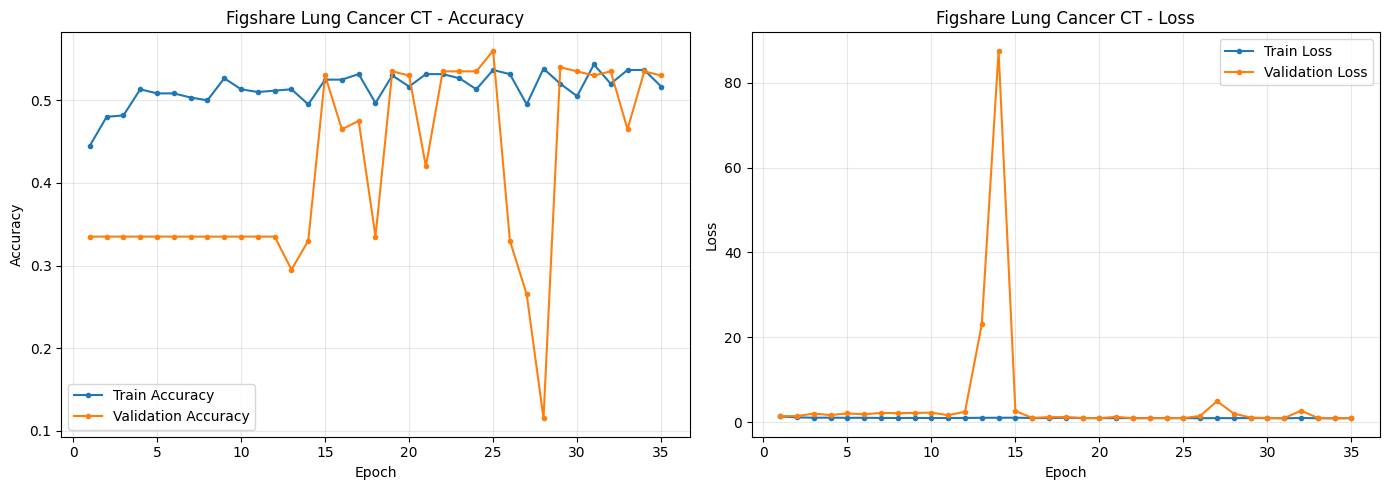

In [11]:
# Train vs Validation Accuracy and Loss curves
epochs_range = range(1, len(history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history.history["accuracy"], label="Train Accuracy", marker="o", markersize=3)
axes[0].plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy", marker="o", markersize=3)
axes[0].set_title(f"{DATASET_NAME} - Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history.history["loss"], label="Train Loss", marker="o", markersize=3)
axes[1].plot(epochs_range, history.history["val_loss"], label="Validation Loss", marker="o", markersize=3)
axes[1].set_title(f"{DATASET_NAME} - Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_loss_curves.png"), dpi=150)
plt.show()


## 11. Validation Precision / Recall / F1 curves (per epoch)

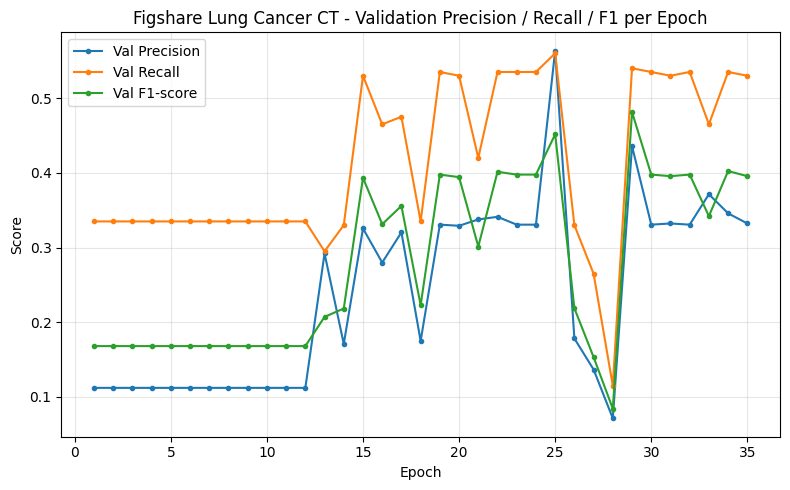

In [12]:
# Validation Precision / Recall / F1 curves across epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, metrics_cb.val_precision, label="Val Precision", marker="o", markersize=3)
plt.plot(epochs_range, metrics_cb.val_recall, label="Val Recall", marker="o", markersize=3)
plt.plot(epochs_range, metrics_cb.val_f1, label="Val F1-score", marker="o", markersize=3)
plt.title(f"{DATASET_NAME} - Validation Precision / Recall / F1 per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_f1_curves.png"), dpi=150)
plt.show()


## 12. Final evaluation on the held-out TEST set

In [13]:
# Final evaluation on the held-out TEST set
test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest loss: {test_loss:.4f}  |  Test accuracy: {test_acc*100:.2f}%")

test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

test_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
test_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
test_accuracy_check = accuracy_score(y_true, y_pred)

print(f"\nTest Precision (weighted): {test_precision:.4f}")
print(f"Test Recall (weighted):    {test_recall:.4f}")
print(f"Test F1-score (weighted):  {test_f1:.4f}")
print(f"Test Accuracy (sklearn):   {test_accuracy_check:.4f}")

print("\nFull classification report:")
report_str = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=TARGET_CLASSES, digits=4, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "test_classification_report.csv"))
report_df


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.5300 - loss: 0.9432

Test loss: 0.9432  |  Test accuracy: 53.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step

Test Precision (weighted): 0.3335
Test Recall (weighted):    0.5300
Test F1-score (weighted):  0.3979
Test Accuracy (sklearn):   0.5300

Full classification report:
                         precision    recall  f1-score   support

         adenocarcinoma     0.4145    0.9265    0.5727        68
squamous_cell_carcinoma     0.0000    0.0000    0.0000        52
   large_cell_carcinoma     0.0000    0.0000    0.0000        37
                 normal     0.8958    1.0000    0.9451        43

               accuracy                         0.5300       200
              macro avg     0.3276    0.4816    0.3794       200
           weighted avg     0.3335    0.5300    0.3979       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

,precision,recall,f1-score,support
adenocarcinoma,0.414474,0.926471,0.572727,68.00
squamous_cell_carcinoma,0.000000,0.000000,0.000000,52.00
large_cell_carcinoma,0.000000,0.000000,0.000000,37.00
normal,0.895833,1.000000,0.945055,43.00
accuracy,0.530000,0.530000,0.530000,0.53
macro avg,0.327577,0.481618,0.379446,200.00
weighted avg,0.333525,0.530000,0.397914,200.00


## 13. Confusion matrix (counts + row-normalized %)

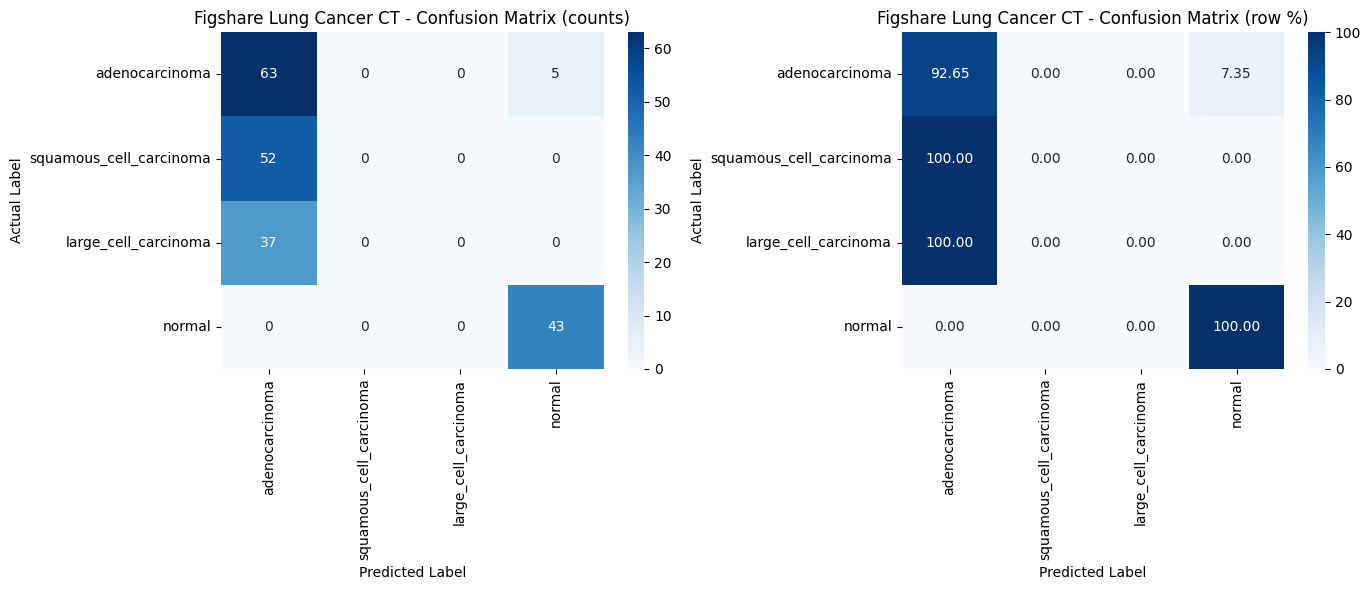

Confusion matrix (raw counts):
 [[63  0  0  5]
 [52  0  0  0]
 [37  0  0  0]
 [ 0  0  0 43]]


In [14]:
# Confusion matrix (counts) and normalized (row-percentage) confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[0])
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")
axes[0].set_title(f"{DATASET_NAME} - Confusion Matrix (counts)")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES, ax=axes[1])
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")
axes[1].set_title(f"{DATASET_NAME} - Confusion Matrix (row %)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

print("Confusion matrix (raw counts):\n", cm)


## 14. Summary bar charts — final test metrics & per-class metrics

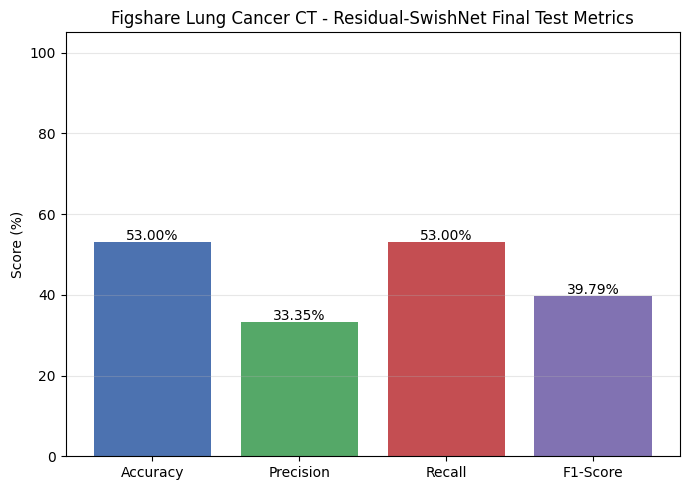

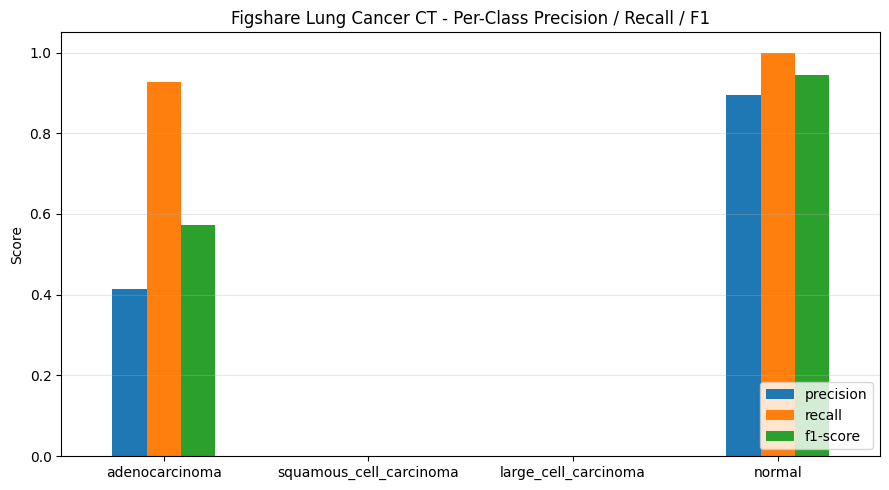

,precision,recall,f1-score
adenocarcinoma,0.414474,0.926471,0.572727
squamous_cell_carcinoma,0.000000,0.000000,0.000000
large_cell_carcinoma,0.000000,0.000000,0.000000
normal,0.895833,1.000000,0.945055


In [15]:
# Bar chart summarizing final test-set Accuracy / Precision / Recall / F1
metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values = [test_acc * 100, test_precision * 100, test_recall * 100, test_f1 * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(metric_names, metric_values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"{val:.2f}%", ha="center", fontsize=10)
plt.ylim(0, 105)
plt.ylabel("Score (%)")
plt.title(f"{DATASET_NAME} - Residual-SwishNet Final Test Metrics")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_metrics_bar_chart.png"), dpi=150)
plt.show()

# Per-class precision / recall / F1 bar chart
per_class_df = report_df.loc[TARGET_CLASSES, ["precision", "recall", "f1-score"]]
per_class_df.plot(kind="bar", figsize=(9, 5), rot=0)
plt.title(f"{DATASET_NAME} - Per-Class Precision / Recall / F1")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_bar_chart.png"), dpi=150)
plt.show()

per_class_df


## 15. Save model, plots, and metrics history

In [16]:
model.save(os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_final.keras"))

with open(os.path.join(OUTPUT_DIR, "history.json"), "w") as f:
    json.dump({
        "train_accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"],
        "train_loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "val_precision": metrics_cb.val_precision,
        "val_recall": metrics_cb.val_recall,
        "val_f1": metrics_cb.val_f1,
        "test_loss": float(test_loss),
        "test_accuracy": float(test_acc),
        "test_precision": float(test_precision),
        "test_recall": float(test_recall),
        "test_f1": float(test_f1),
    }, f, indent=2)

print(f"Saved model, plots, and metrics history to: {OUTPUT_DIR}")


Saved model, plots, and metrics history to: /kaggle/working/residual_swishnet_figshare
